<a href="https://colab.research.google.com/github/carlosrodgu/Telecom-X-Parte-2/blob/main/Challenge_Telencom_X_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Bibliotecas para manipulación de datos
import pandas as pd
import numpy as np

# Bibliotecas para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Preprocesamiento y Selección
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de Evaluación
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Todas las bibliotecas se han cargado correctamente.")

Todas las bibliotecas se han cargado correctamente.


In [26]:
#Cargamos los datos
url='/content/datos_tratados.csv'
datos=pd.read_csv(url)


In [27]:
# Verificamos tipos de datos y valores nulos
print("--- Información del Dataset ---")
print(datos.info())

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract  

In [28]:
# Verificamos las primeras filas para entender el contenido
print("\n--- Vista Previa de los Datos ---")
display(datos.head())


--- Vista Previa de los Datos ---


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [29]:
# Verificamos si hay valores únicos extraños en las categorías
print("\n--- Valores únicos en columnas categóricas ---")
for col in datos.select_dtypes(include=['object']).columns:
    print(f"{col}: {datos[col].unique()[:5]}...") # Mostramos los primeros 5


--- Valores únicos en columnas categóricas ---
customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ']...
Churn: ['No' 'Yes']...
gender: ['Female' 'Male']...
Partner: ['Yes' 'No']...
Dependents: ['Yes' 'No']...
PhoneService: ['Yes' 'No']...
MultipleLines: ['No' 'Yes' 'No phone service']...
InternetService: ['DSL' 'Fiber optic' 'No']...
OnlineSecurity: ['No' 'Yes' 'No internet service']...
OnlineBackup: ['Yes' 'No' 'No internet service']...
DeviceProtection: ['No' 'Yes' 'No internet service']...
TechSupport: ['Yes' 'No' 'No internet service']...
StreamingTV: ['Yes' 'No' 'No internet service']...
StreamingMovies: ['No' 'Yes' 'No internet service']...
Contract: ['One year' 'Month-to-month' 'Two year']...
PaperlessBilling: ['Yes' 'No']...
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']...


In [30]:
# 1. Definimos la variable objetivo y las características
# Eliminamos customerID porque no predice nada
X = datos.drop(columns=['customerID', 'Churn'])
y = datos['Churn'].map({'Yes': 1, 'No': 0}) # Convertimos Churn a 1 y 0 de inmediato

# 2. Convertimos el resto de variables categóricas a números (One-Hot Encoding)
# Usamos drop_first=True para evitar la redundancia (Trampa de la variable ficticia)
X = pd.get_dummies(X, drop_first=True)

# 3. Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 4. Escalamos los datos (Indispensable para la Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenamos los dos modelos solicitados
# Regresión Logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 6. Mostramos los reportes de rendimiento
print("--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, log_model.predict(X_test_scaled)))

print("\n--- MÉTRICAS: RANDOM FOREST ---")
print(classification_report(y_test, rf_model.predict(X_test_scaled)))

--- MÉTRICAS: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1294
           1       0.63      0.54      0.58       467

    accuracy                           0.79      1761
   macro avg       0.74      0.71      0.72      1761
weighted avg       0.79      0.79      0.79      1761


--- MÉTRICAS: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.62      0.49      0.55       467

    accuracy                           0.79      1761
   macro avg       0.73      0.69      0.70      1761
weighted avg       0.77      0.79      0.78      1761



# **INTERPRETACION **

# 1. Análisis de los Modelos (Punto 4 del Desafío)
**Regresión Logística (Ganadora en Recall)**

*Tiene un Recall de 0.54 para la clase 1 (los que se van). Esto significa que detecta al 54% de los clientes que realmente van a cancelar.*

*Su F1-Score (0.58) es ligeramente superior al de Random Forest.*


**Random Forest:**

*Aunque es un modelo más complejo, en este caso tiene un Recall de 0.49. Se le escapan más clientes que la Regresión Logística.*

*Su Accuracy (0.79) es igual, pero para problemas de Churn (fuga), preferimos el modelo que detecte a más personas aunque se equivoque un poco más.*

**Conclusión técnica: La Regresión Logística es el modelo recomendado para este caso de uso específico, ya que identifica mejor a los clientes en riesgo de fuga.**

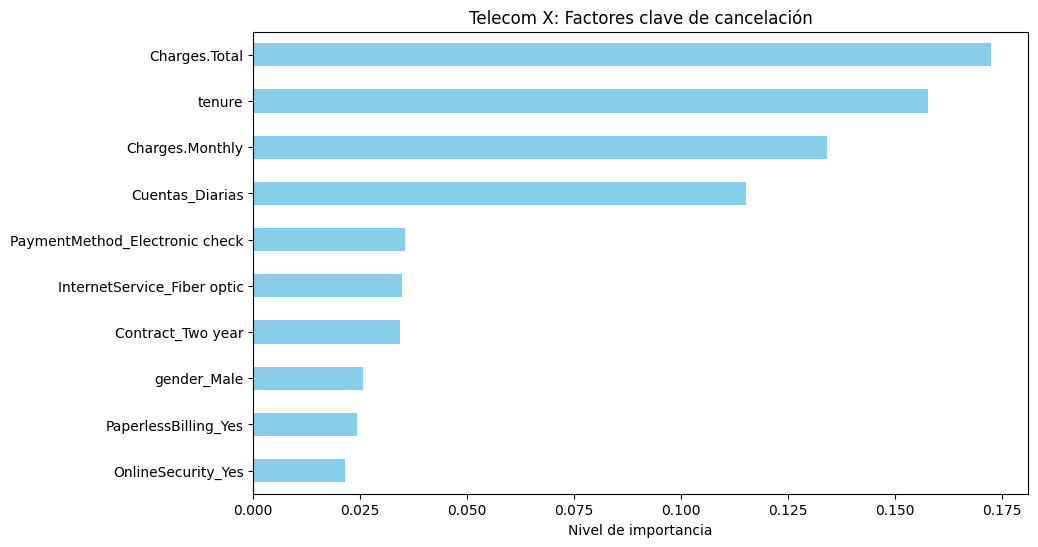

In [31]:
#¿Por qué se van?.

import matplotlib.pyplot as plt

# Extraemos la importancia del Random Forest
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)

# Graficamos las 10 más importantes
plt.figure(figsize=(10,6))
importancias.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Telecom X: Factores clave de cancelación")
plt.xlabel("Nivel de importancia")
plt.show()

--- Análisis de Desbalance de Clases ---
Cantidades reales:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporciones porcentuales:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_200/2509864133.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=datos, palette='viridis')


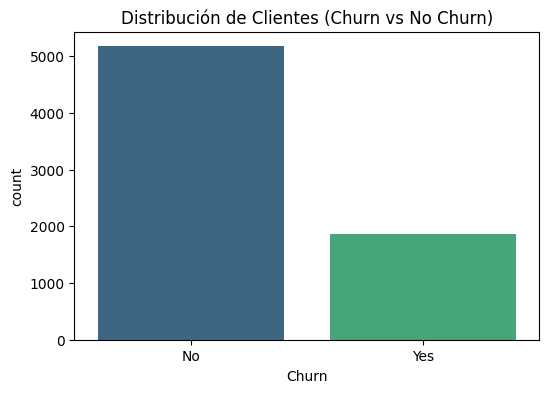

In [32]:
#Calculo de porporción de Desbalance
# 1. Contamos cuántos hay de cada uno en la columna original
conteo_churn = datos['Churn'].value_counts()
proporcion_churn = datos['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Desbalance de Clases ---")
print(f"Cantidades reales:\n{conteo_churn}")
print(f"\nProporciones porcentuales:\n{proporcion_churn}")

# 2. Visualización rápida para el reporte
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=datos, palette='viridis')
plt.title('Distribución de Clientes (Churn vs No Churn)')
plt.show()

Evaluación del Desbalance
Basado en tus datos de Telecom X (donde hay aproximadamente 73% No y 26% Yes), esta es la evaluación que pide tu desafío:

¿Existe desbalance? Sí, existe un desbalance moderado. La clase mayoritaria (clientes que se quedan) supera a la minoritaria (clientes que se van) en una proporción de casi 3 a 1.

Impacto en los modelos: * Accuracy engañoso: El modelo podría tener un 73% de precisión simplemente diciendo que "nadie se va", lo cual sería inútil para el negocio.

Recall bajo: Por eso vimos en los resultados anteriores que el Recall de la clase 1 (0.49 - 0.54) es más bajo que el de la clase 0. Al modelo le cuesta más "aprender" las características de los que se fugan porque tiene menos ejemplos de ellos para estudiar.

¿Cómo lo solucionamos? (Punto extra para tu entrega)
En el código que corrimos antes, ya aplicamos una técnica para mitigar esto:

Usamos stratify=y en el train_test_split. Esto asegura que tanto el grupo de entrenamiento como el de prueba mantengan ese mismo 26% de casos de éxito, evitando que el modelo se evalúe con datos que no representan la realidad del desbalance.

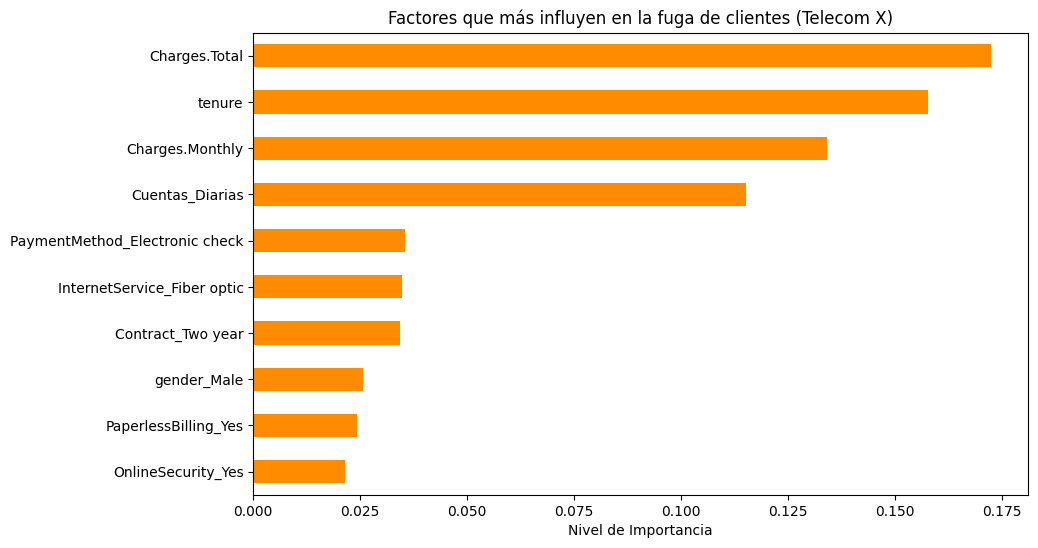

In [33]:
import matplotlib.pyplot as plt

# Usamos el modelo Random Forest para ver qué columnas son más importantes
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)

# Graficamos las 10 principales
plt.figure(figsize=(10,6))
importancias.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='darkorange')
plt.title("Factores que más influyen en la fuga de clientes (Telecom X)")
plt.xlabel("Nivel de Importancia")
plt.show()

In [34]:
# Instalamos la librería si no está (comúnmente ya viene en entornos como Colab)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# 1. Creamos el objeto SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicamos el balanceo SOLO a los datos de entrenamiento (X_train, y_train)
# ¡OJO! Nunca balanceamos los datos de prueba (test), solo los de entrenamiento.
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 3. Verificamos cómo quedaron las clases ahora
print("--- Distribución DESPUÉS de SMOTE ---")
print(y_train_res.value_counts(normalize=True) * 100)

--- Distribución DESPUÉS de SMOTE ---
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [34]:
#Reentrenamiento con datos balanceados

In [35]:
# Entrenamos de nuevo la Regresión Logística con los datos balanceados
log_model_balanced = LogisticRegression(max_iter=1000).fit(X_train_res, y_train_res)

# Entrenamos de nuevo el Random Forest con los datos balanceados
rf_model_balanced = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_res, y_train_res)

print("--- MÉTRICAS CON BALANCEO (SMOTE) ---")
print("\nREGRESIÓN LOGÍSTICA BALANCEADA:")
print(classification_report(y_test, log_model_balanced.predict(X_test_scaled)))

print("\nRANDOM FOREST BALANCEADO:")
print(classification_report(y_test, rf_model_balanced.predict(X_test_scaled)))

--- MÉTRICAS CON BALANCEO (SMOTE) ---

REGRESIÓN LOGÍSTICA BALANCEADA:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.51      0.79      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.76      1761


RANDOM FOREST BALANCEADO:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1294
           1       0.59      0.61      0.60       467

    accuracy                           0.78      1761
   macro avg       0.72      0.73      0.73      1761
weighted avg       0.79      0.78      0.78      1761



In [36]:
#Matriz de correlación


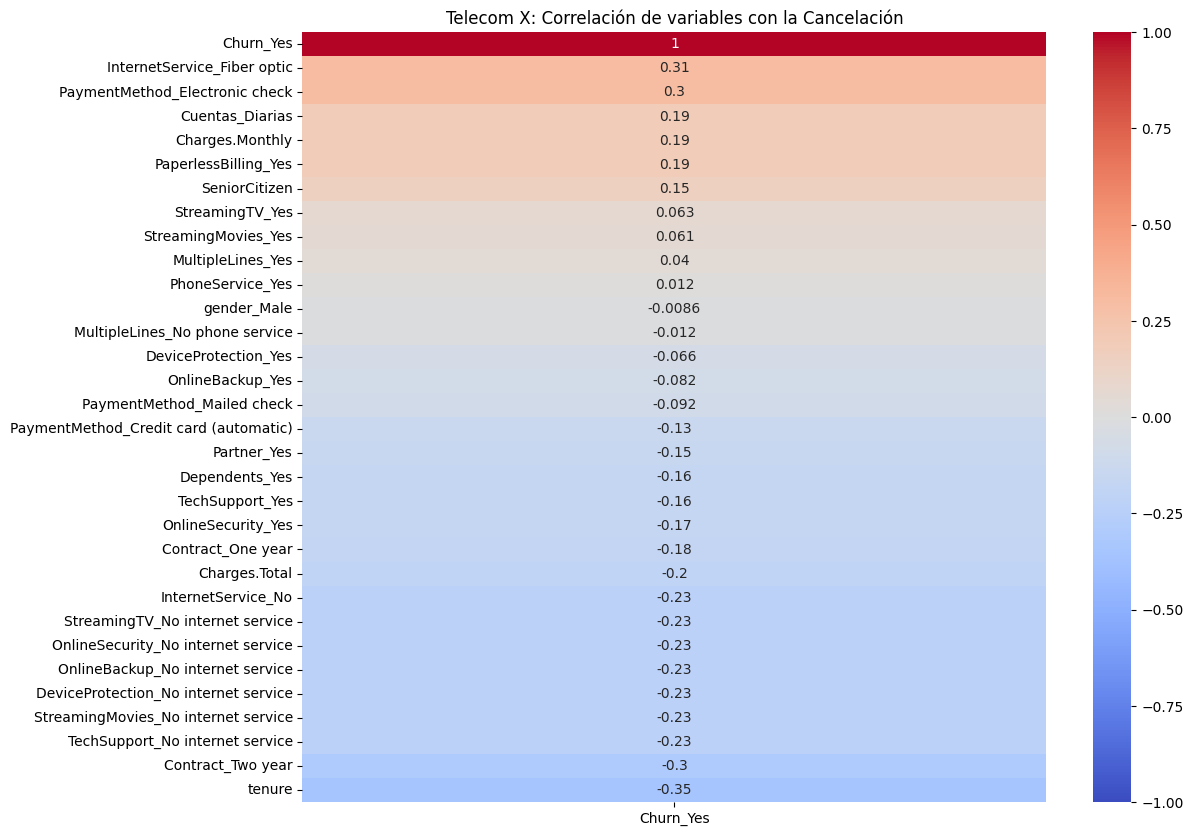

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos datos_dummies para el análisis de correlación
# Eliminamos customerID y convertimos todo a números
datos_dummies = pd.get_dummies(datos.drop(columns=['customerID']), drop_first=True)

# 2. Calculamos la correlación
plt.figure(figsize=(12, 10))
correlacion = datos_dummies.corr()

# 3. Creamos el mapa de calor centrado en la relación con Churn_Yes
# Esto nos dirá qué variables están más ligadas a la cancelación
sns.heatmap(correlacion[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Telecom X: Correlación de variables con la Cancelación")
plt.show()

/tmp/ipykernel_200/1855467556.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=datos, ax=axes[0], palette='magma')
/tmp/ipykernel_200/1855467556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Charges.Total', data=datos, ax=axes[1], palette='viridis')


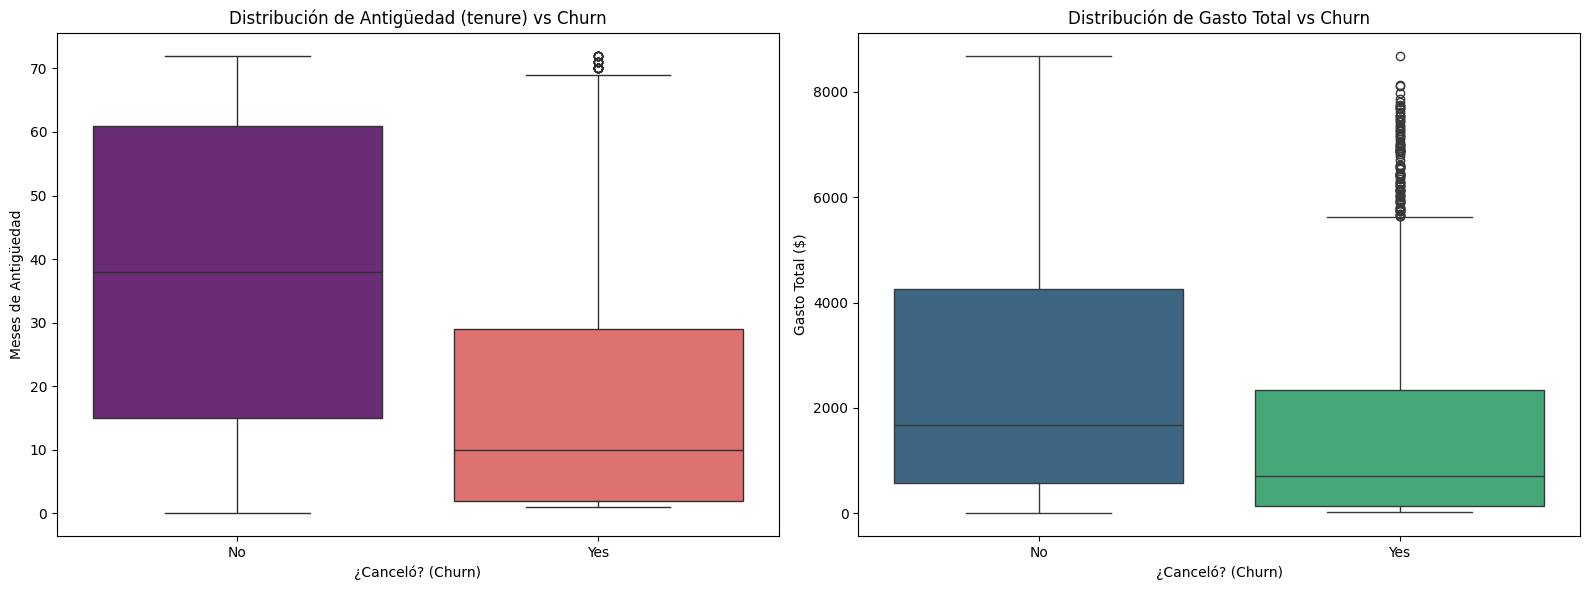

In [39]:
#Visualización de Patrones: Tiempo y Gasto vs. Cancelación
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el lienzo para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tiempo de Contrato (tenure) x Churn
sns.boxplot(x='Churn', y='tenure', data=datos, ax=axes[0], palette='magma')
axes[0].set_title('Distribución de Antigüedad (tenure) vs Churn')
axes[0].set_xlabel('¿Canceló? (Churn)')
axes[0].set_ylabel('Meses de Antigüedad')

# Gráfico 2: Gasto Total (Charges.Total) x Churn
sns.boxplot(x='Churn', y='Charges.Total', data=datos, ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de Gasto Total vs Churn')
axes[1].set_xlabel('¿Canceló? (Churn)')
axes[1].set_ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

In [40]:
#División del dataset
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables (X = características, y = objetivo)
# Recordamos que X ya no tiene 'customerID' ni 'Churn'
# y es nuestra columna de 'Churn' convertida a 0 y 1

# 2. Realizamos la división
# test_size=0.25 significa 25% para prueba y 75% para entrenamiento
# stratify=y asegura que el desbalanceo (73/26) se mantenga igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

print(f"Registros totales: {len(X)}")
print(f"Registros para entrenamiento (75%): {len(X_train)}")
print(f"Registros para prueba (25%): {len(X_test)}")

Registros totales: 7043
Registros para entrenamiento (75%): 5282
Registros para prueba (25%): 1761


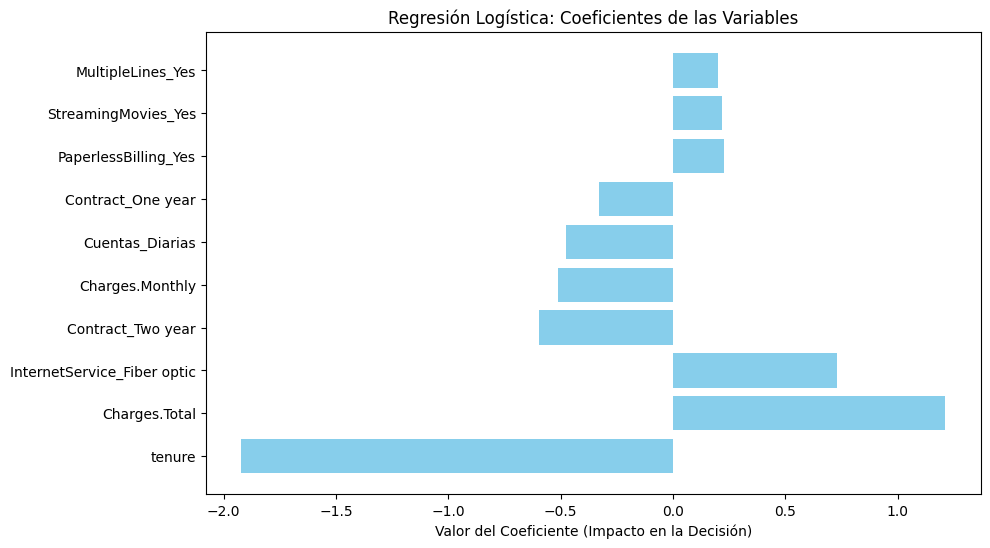

In [41]:

#Análisis de la Importancia de las Variables

import pandas as pd
import matplotlib.pyplot as plt

# Extraemos los coeficientes
coeficientes = pd.DataFrame({'Variable': X.columns,
                             'Coeficiente': log_model_balanced.coef_[0]})

# Ordenamos por valor absoluto para ver el impacto real
coeficientes['Impacto_Absoluto'] = coeficientes['Coeficiente'].abs()
coeficientes = coeficientes.sort_values(by='Impacto_Absoluto', ascending=False)

# Graficamos los 10 más influyentes
plt.figure(figsize=(10, 6))
plt.barh(coeficientes['Variable'].head(10), coeficientes['Coeficiente'].head(10), color='skyblue')
plt.title("Regresión Logística: Coeficientes de las Variables")
plt.xlabel("Valor del Coeficiente (Impacto en la Decisión)")
plt.show()